In [6]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score
)
import warnings
warnings.filterwarnings('ignore')

In [7]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [8]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
path

'C:\\Users\\admin\\.cache\\kagglehub\\datasets\\mlg-ulb\\creditcardfraud\\versions\\3'

## Data
- 2013.09 Credit card payment history of European cardholders for binary classification

In [9]:
df = pd.read_csv(f"{path}/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [10]:
df.shape

(284807, 31)

In [11]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [12]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
df.sample(5, random_state=42)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


- Time: Time elapsed since first transaction (in seconds)
- V1 to V28 : Anonymized features transformed using PCA
- Amount : transaction amount

In [14]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Check The Target Data

In [17]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [18]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

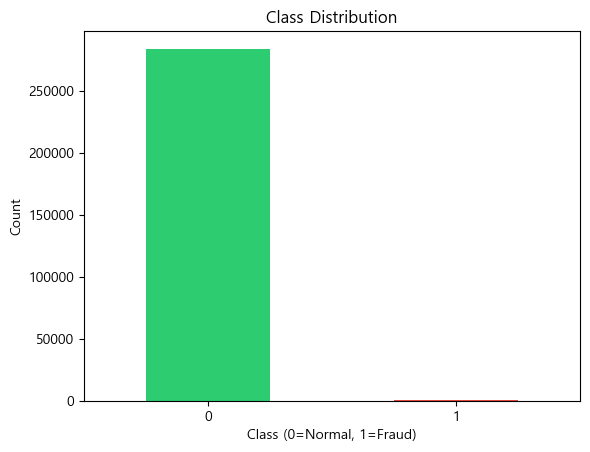

In [19]:
df['Class'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## main features

In [20]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

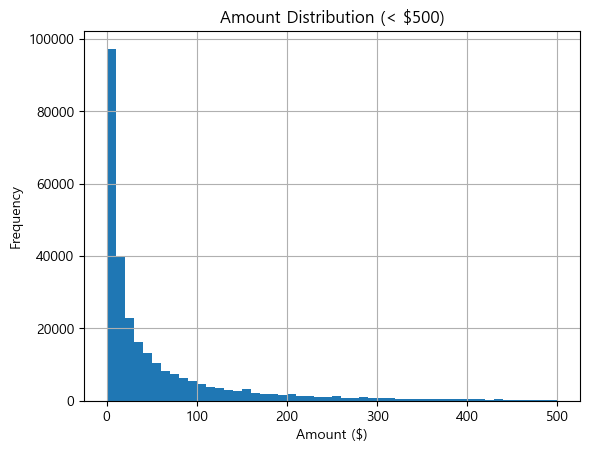

In [21]:
df[df['Amount'] < 500]['Amount'].hist(bins=50)
plt.title('Amount Distribution (< $500)')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.show()

In [22]:
normal_df = df[df['Class'] == 0]
fraud_df = df[df['Class'] == 1]

In [23]:
normal_df['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [24]:
fraud_df['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

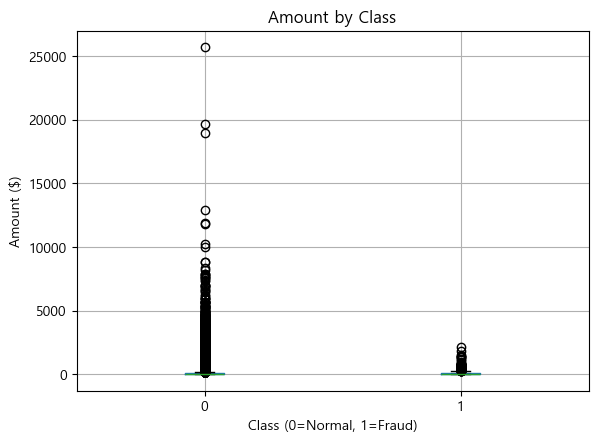

In [25]:
df.boxplot(column='Amount', by='Class')
plt.title('Amount by Class')
plt.suptitle('')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Amount ($)')
plt.show()

In [26]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

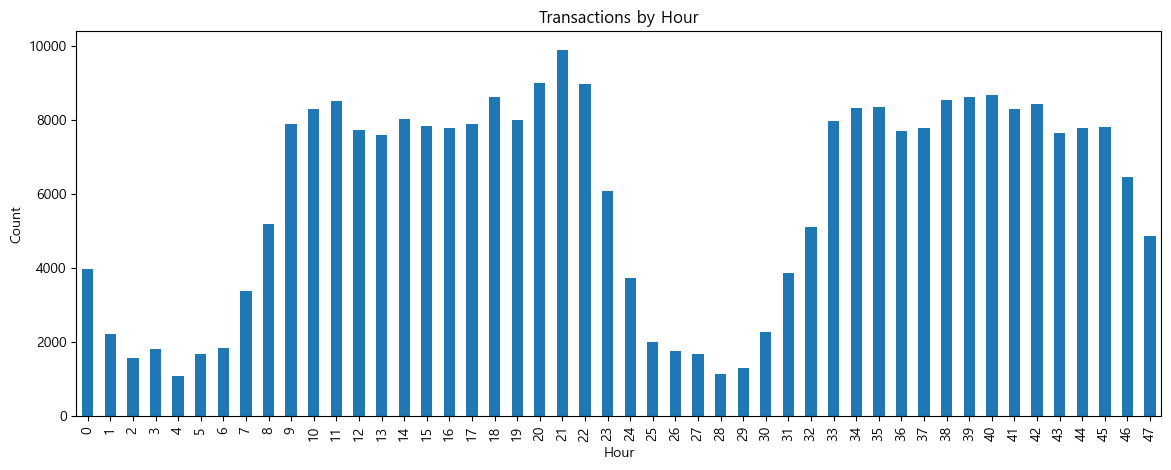

In [27]:
# WARN: Time is just elapsed time, so it has nothing to do with the two-day hour.
df['Hour'] = (df['Time'] / 3600).astype(int)
df['Hour'].value_counts().sort_index().plot(kind='bar', figsize=(14, 5))
plt.title('Transactions by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

### v1~v28 features

In [28]:
v_features = [f'V{i}' for i in range(1, 29)]
v_features

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28']

In [29]:
# CHECK : PCA of dimensionality reductions features - from kaggle (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
df[v_features].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
V1,1.175161e-15,1.958696,-56.407510,2.454930
V2,3.384974e-16,1.651309,-72.715728,22.057729
V3,-1.379537e-15,1.516255,-48.325589,9.382558
V4,2.094852e-15,1.415869,-5.683171,16.875344
V5,1.021879e-15,1.380247,-113.743307,34.801666
V6,1.494498e-15,1.332271,-26.160506,73.301626
V7,-5.620335e-16,1.237094,-43.557242,120.589494
V8,1.149614e-16,1.194353,-73.216718,20.007208
V9,-2.414189e-15,1.098632,-13.434066,15.594995
V10,2.238554e-15,1.088850,-24.588262,23.745136


## Correlation with Class

In [30]:
correlations = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
correlations.head(10)

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64

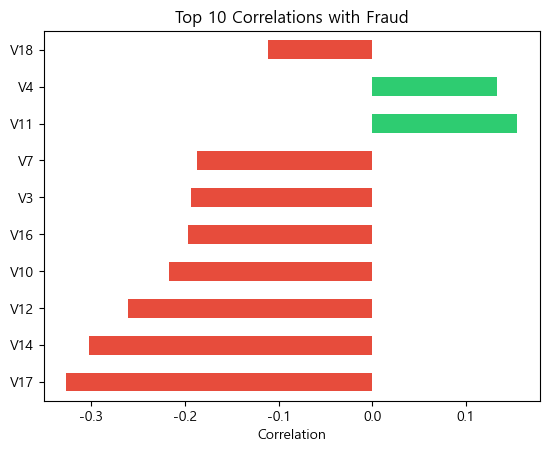

In [31]:
correlations.head(10).plot(kind='barh', color=['#e74c3c' if x < 0 else '#2ecc71' for x in correlations.head(10)])
plt.title('Top 10 Correlations with Fraud')
plt.xlabel('Correlation')
plt.show()

## Rule Based

In [32]:
def test_rule(threshold):
    predicted_fraud = df['Amount'] > threshold
    actual_fraud = df['Class'] == 1
    
    tp = ((predicted_fraud) & (actual_fraud)).sum()
    fp = ((predicted_fraud) & (~actual_fraud)).sum()
    fn = ((~predicted_fraud) & (actual_fraud)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'threshold': threshold, 'tp': tp, 'fp': fp, 'fn': fn, 
            'precision': precision, 'recall': recall, 'f1': f1}

In [33]:
thresholds = [50, 100, 200, 500, 1000, 2000]
rule_results = [test_rule(t) for t in thresholds]
rule_df = pd.DataFrame(rule_results)
rule_df

,threshold,tp,fp,fn,precision,recall,f1
0,50,186,93576,306,0.001984,0.378049,0.003947
1,100,130,56378,362,0.002301,0.264228,0.004561
2,200,85,28752,407,0.002948,0.172764,0.005796
3,500,35,9107,457,0.003828,0.071138,0.007266
4,1000,9,2931,483,0.003061,0.018293,0.005245
5,2000,1,675,491,0.001479,0.002033,0.001712


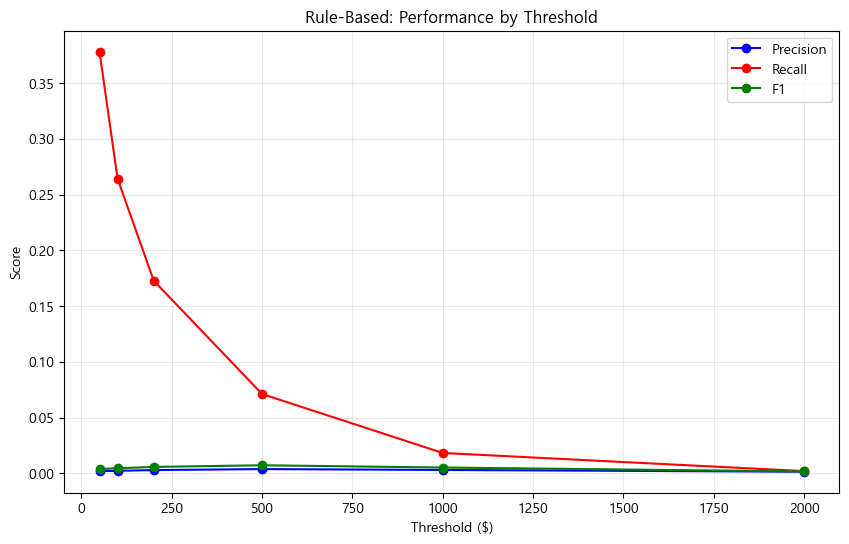

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rule_df['threshold'], rule_df['precision'], 'b-o', label='Precision')
ax.plot(rule_df['threshold'], rule_df['recall'], 'r-o', label='Recall')
ax.plot(rule_df['threshold'], rule_df['f1'], 'g-o', label='F1')
ax.set_xlabel('Threshold ($)')
ax.set_ylabel('Score')
ax.set_title('Rule-Based: Performance by Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [35]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, f1_score, accuracy_score)

## ML

In [36]:
X = df.drop(['Class', 'Hour'], axis=1)
y = df['Class']

print(f"feature shape: {X.shape}")
print(f"target shape: {y.shape}")

feature shape: (284807, 30)
target shape: (284807,)


In [37]:
scaler = StandardScaler()
X['Amount_scaled'] = scaler.fit_transform(X[['Amount']])
X['Time_scaled'] = scaler.fit_transform(X[['Time']])
X = X.drop(['Amount', 'Time'], axis=1)

X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,-1.996541


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"train: {len(X_train):,}")
print(f"test: {len(X_test):,}")

train: 199,364
test: 85,443


In [39]:
print(f"fraud ratio in train set: {y_train.mean()*100:.3f}%")
print(f"fraud ratio in test set: {y_test.mean()*100:.3f}%")

fraud ratio in train set: 0.173%
fraud ratio in test set: 0.173%


### Logistic Regression
- use Sigmoid function

In [40]:

lr_basic = LogisticRegression(max_iter=1000, random_state=42)
lr_basic.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [41]:
y_pred_lr = lr_basic.predict(X_test)
y_prob_lr = lr_basic.predict_proba(X_test)[:, 1]

In [42]:
print("Logistic Regression")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"  AUPRC: {average_precision_score(y_test, y_prob_lr):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression
  Accuracy: 0.9992
  F1 Score: 0.7165
  AUPRC: 0.7079
  ROC-AUC: 0.9560


In [43]:
y_train_pred = lr_basic.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)

print(f"Train F1 Score: {train_f1:.4f}")
print(f"Test F1 Score: {0.7165}")

Train F1 Score: 0.7517
Test F1 Score: 0.7165


In [65]:
from sklearn.metrics import classification_report
y_pred = lr_basic.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



### Logistic Regression with Weight By Class

In [44]:
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_balanced.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [45]:
y_pred_lr_bal = lr_balanced.predict(X_test)
y_prob_lr_bal = lr_balanced.predict_proba(X_test)[:, 1]

In [66]:
print(classification_report(y_test, y_pred_lr_bal))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



#### Confusion matrix
TN FP </br>
FN TP </br>

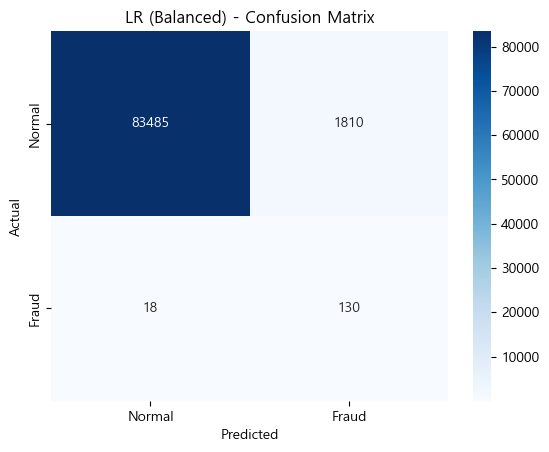

In [46]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_bal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('LR (Balanced) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [47]:
print(f"   F1 Score: {f1_score(y_test, y_pred_lr):.4f} → {f1_score(y_test, y_pred_lr_bal):.4f}")

   F1 Score: 0.7165 → 0.1245


### Random Forest

In [48]:
## Random Forest (basic)
rf_basic = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_basic.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
y_pred_rf = rf_basic.predict(X_test)
y_prob_rf = rf_basic.predict_proba(X_test)[:, 1]

In [50]:
print("Random Forest")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"  AUPRC: {average_precision_score(y_test, y_prob_rf):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest
  Accuracy: 0.9995
  F1 Score: 0.8421
  AUPRC: 0.8172
  ROC-AUC: 0.9374


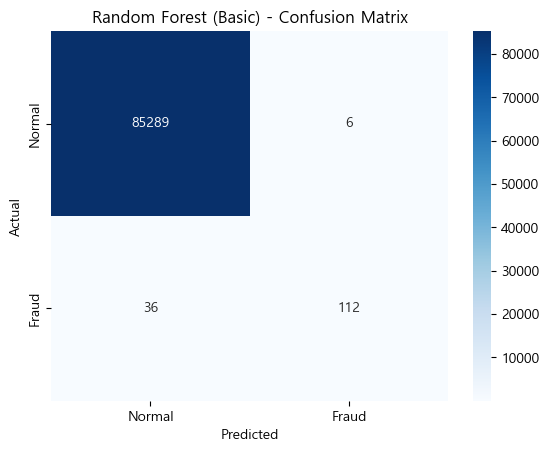

In [51]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Random Forest (Basic) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Tuned Random forest

In [52]:

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [53]:
y_pred_rf_tuned = rf_tuned.predict(X_test)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

In [54]:
print("tuned Random Forest:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  AUPRC: {average_precision_score(y_test, y_prob_rf_tuned):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")

tuned Random Forest:
  Accuracy: 0.9994
  F1 Score: 0.8061
  AUPRC: 0.8144
  ROC-AUC: 0.9488


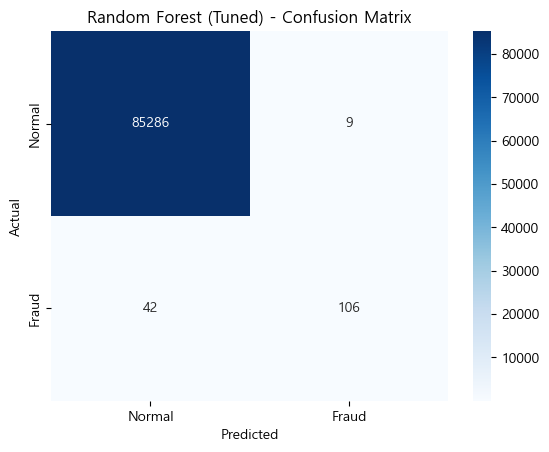

In [55]:
cm = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Random Forest (Tuned) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Total

In [56]:
results = [
    {'Model': 'LR (Basic)', 
     'Accuracy': accuracy_score(y_test, y_pred_lr),
     'F1': f1_score(y_test, y_pred_lr),
     'AUPRC': average_precision_score(y_test, y_prob_lr),
     'ROC-AUC': roc_auc_score(y_test, y_prob_lr)},
    {'Model': 'LR (Balanced)', 
     'Accuracy': accuracy_score(y_test, y_pred_lr_bal),
     'F1': f1_score(y_test, y_pred_lr_bal),
     'AUPRC': average_precision_score(y_test, y_prob_lr_bal),
     'ROC-AUC': roc_auc_score(y_test, y_prob_lr_bal)},
    {'Model': 'RF (Basic)', 
     'Accuracy': accuracy_score(y_test, y_pred_rf),
     'F1': f1_score(y_test, y_pred_rf),
     'AUPRC': average_precision_score(y_test, y_prob_rf),
     'ROC-AUC': roc_auc_score(y_test, y_prob_rf)},
    {'Model': 'RF (Tuned)', 
     'Accuracy': accuracy_score(y_test, y_pred_rf_tuned),
     'F1': f1_score(y_test, y_pred_rf_tuned),
     'AUPRC': average_precision_score(y_test, y_prob_rf_tuned),
     'ROC-AUC': roc_auc_score(y_test, y_prob_rf_tuned)}
]

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1,AUPRC,ROC-AUC
0,LR (Basic),0.999157,0.716535,0.707883,0.955981
1,LR (Balanced),0.978606,0.124521,0.704138,0.967972
2,RF (Basic),0.999508,0.842105,0.817228,0.937393
3,RF (Tuned),0.999403,0.806084,0.814405,0.948754


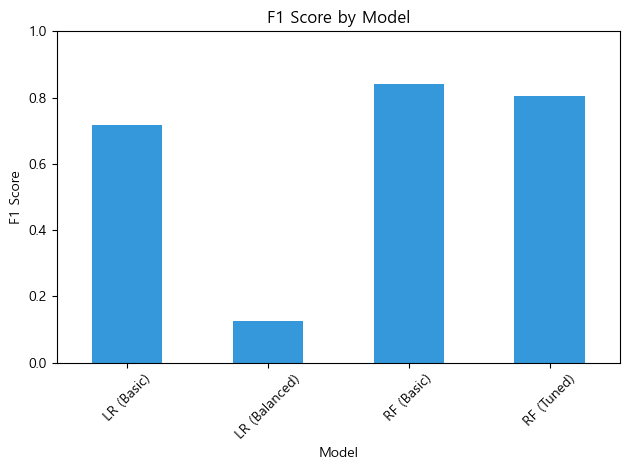

In [57]:
results_df.plot(x='Model', y='F1', kind='bar', legend=False, color='#3498db')
plt.title('F1 Score by Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

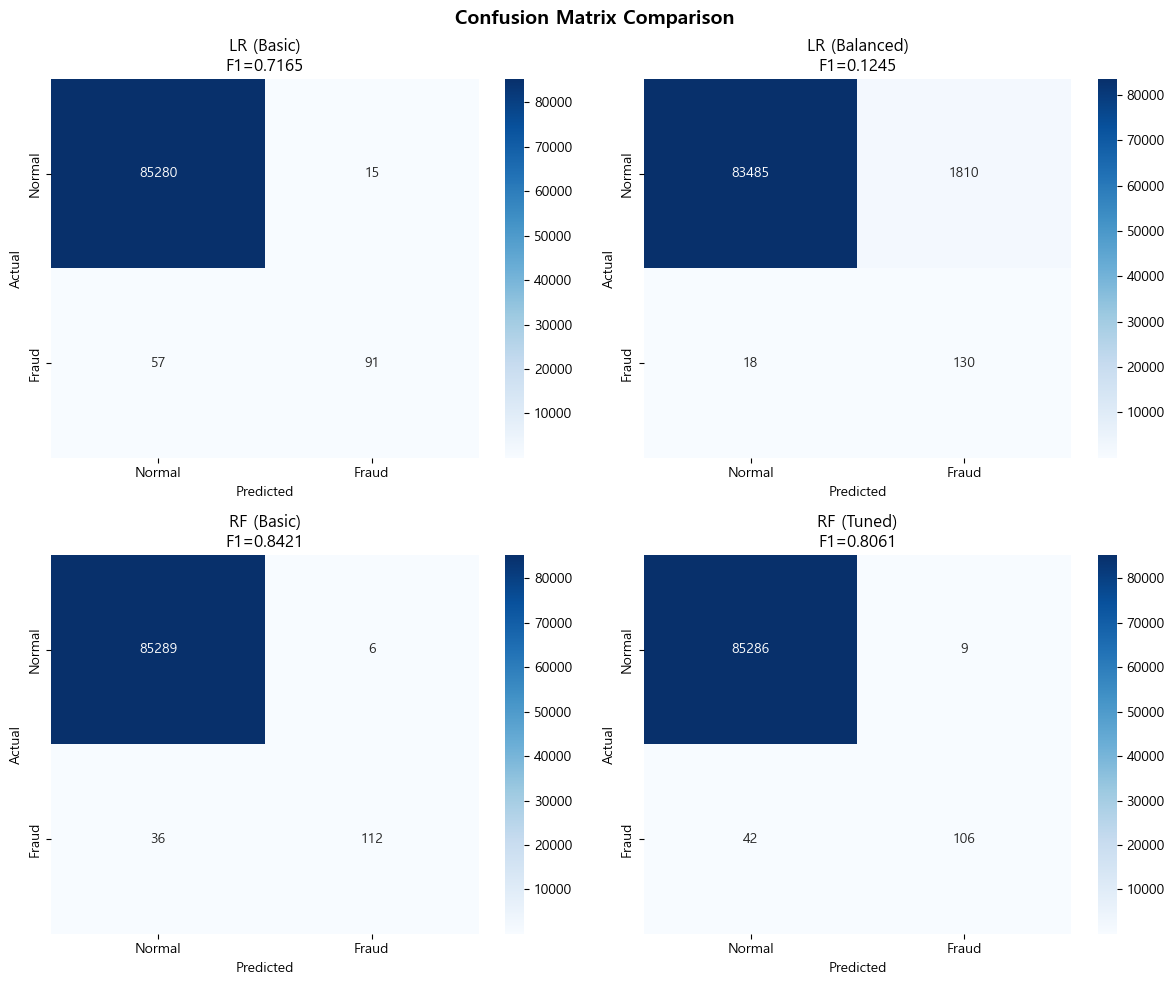

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_data = [
    ('LR (Basic)', y_pred_lr),
    ('LR (Balanced)', y_pred_lr_bal),
    ('RF (Basic)', y_pred_rf),
    ('RF (Tuned)', y_pred_rf_tuned)
]

for ax, (name, y_pred) in zip(axes.flatten(), models_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    ax.set_title(f'{name}\nF1={f1_score(y_test, y_pred):.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

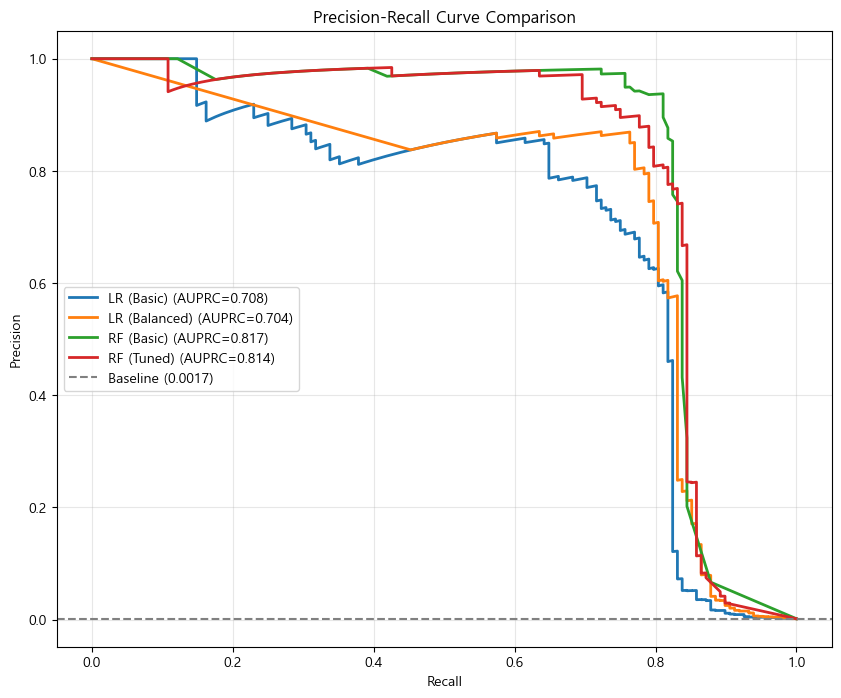

In [59]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, y_prob in [('LR (Basic)', y_prob_lr), ('LR (Balanced)', y_prob_lr_bal),
                      ('RF (Basic)', y_prob_rf), ('RF (Tuned)', y_prob_rf_tuned)]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, label=f'{name} (AUPRC={ap:.3f})', linewidth=2)

ax.axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve Comparison')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.show()

In [60]:
# adjust the threshold
y_prob = y_prob_rf_tuned

threshold_results = []
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_th = (y_prob >= threshold).astype(int)
    
    tp = ((y_pred_th == 1) & (y_test == 1)).sum()
    fp = ((y_pred_th == 1) & (y_test == 0)).sum()
    fn = ((y_pred_th == 0) & (y_test == 1)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    threshold_results.append({'threshold': threshold, 'precision': precision, 
                              'recall': recall, 'f1': f1})

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1
0,0.1,0.651042,0.844595,0.735294
1,0.2,0.775641,0.817568,0.796053
2,0.3,0.873134,0.790541,0.829787
3,0.4,0.895161,0.750000,0.816176
4,0.5,0.921739,0.716216,0.806084
5,0.6,0.962617,0.695946,0.807843
6,0.7,0.970000,0.655405,0.782258
7,0.8,0.977273,0.581081,0.728814
8,0.9,0.984375,0.425676,0.594340


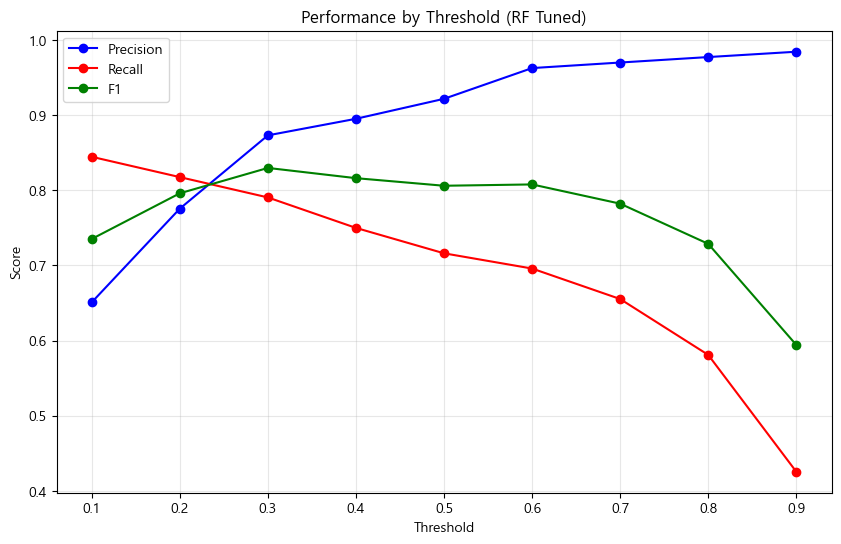

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df['threshold'], threshold_df['precision'], 'b-o', label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], 'r-o', label='Recall')
ax.plot(threshold_df['threshold'], threshold_df['f1'], 'g-o', label='F1')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance by Threshold (RF Tuned)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [62]:
best_idx = threshold_df['f1'].idxmax()
best_threshold = threshold_df.loc[best_idx, 'threshold']
best_f1 = threshold_df.loc[best_idx, 'f1']

print(f"best threshold: {best_threshold}")
print(f"best thrshod's F1 Score: {best_f1:.4f}")

best threshold: 0.3
best thrshod's F1 Score: 0.8298


In [63]:
rule_best_f1 = rule_df['f1'].max()
ml_best_f1 = results_df['F1'].max()
print(f"LR : {rule_best_f1}")
print(f"random forest : {ml_best_f1}")

LR : 0.007265933153414989
random forest : 0.8421052631578947


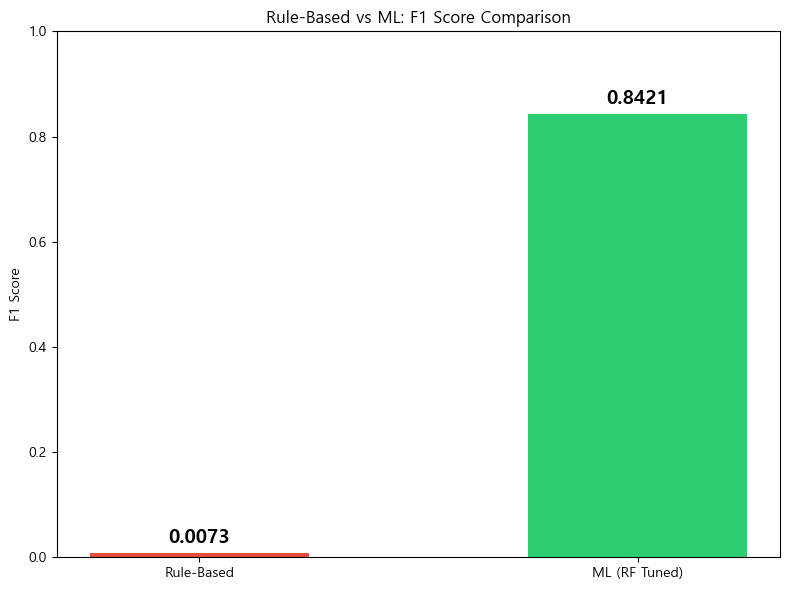

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))

methods = ['Rule-Based', 'ML (RF Tuned)']
f1_scores = [rule_best_f1, ml_best_f1]

bars = ax.bar(methods, f1_scores, color=['#e74c3c', '#2ecc71'], width=0.5)
ax.set_ylabel('F1 Score')
ax.set_title('Rule-Based vs ML: F1 Score Comparison')
ax.set_ylim(0, 1)

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{score:.4f}', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()